<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_006_reduccion_de_dimensiones/001_PCA_Explicaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🧠 1: Introducción a PCA - Análisis de Componentes Principales

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad utilizada en el análisis exploratorio de datos y en el aprendizaje automático. Su objetivo es transformar un conjunto de variables posiblemente correlacionadas en un conjunto más pequeño de variables no correlacionadas llamadas **componentes principales**.

**Ventajas de PCA:**
- Reduce la dimensionalidad de los datos.
- Elimina redundancia al reducir correlaciones.
- Mejora la eficiencia de algoritmos de machine learning.

---


# 📐 2: Fundamento Matemático

Supongamos un conjunto de datos $ X \in \mathbb{R}^{n \times p} $, donde:
- $ n $ es el número de observaciones (filas).
- $ p $ es el número de variables (columnas).

## Paso 1: Centrado de los datos
Restamos la media de cada columna (variable):

$$
X_{\text{centrado}} = X - \bar{X}
$$

## Paso 2: Cálculo de la matriz de covarianza

$$
\Sigma = \frac{1}{n-1} X_{\text{centrado}}^T X_{\text{centrado}}
$$

## Paso 3: Descomposición en valores propios

$$
\Sigma = V \Lambda V^T
$$

Donde:
- $ V $ contiene los **vectores propios** (direcciones de los componentes).
- $ \Lambda $ Lambda contiene los **valores propios** (varianza explicada por cada componente).

## Paso 4: Proyección de los datos

$$
Z = X_{\text{centrado}} V_k
$$

Donde $ V_k $ son los primeros $ k $ vectores propios que explican mayor varianza.


#🧪 3: Ejemplo práctico con Python

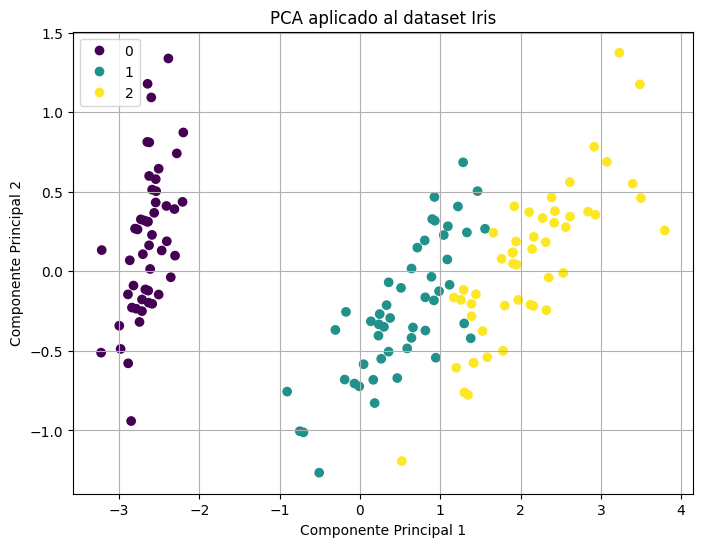

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Cargar conjunto de datos Iris
data = load_iris()
X = data.data
y = data.target

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizar resultados
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA aplicado al dataset Iris')
handles, labels = scatter.legend_elements()
plt.legend(handles, labels)
plt.grid(True)
plt.show()


# 📊 4: Interpretación y selección de componentes

## Interpretación de los Componentes Principales

Cada componente principal es una combinación lineal de las variables originales. Por ejemplo, el primer componente principal es la dirección en la que los datos varían más. El segundo componente es ortogonal al primero y explica la siguiente mayor varianza, y así sucesivamente.

El PCA proporciona los **loadings** o **pesos**, que indican cuánto contribuye cada variable original a cada componente.

---

## ¿Cuántos Componentes conservar?

Para decidir cuántos componentes principales conservar, se puede usar:

### 1. Varianza explicada acumulada

La varianza explicada por cada componente nos indica cuánta información (varianza) de los datos originales está contenida en ese componente. Se recomienda conservar los componentes que explican al menos el 95% de la varianza total.

### 2. Gráfico de Codo (Scree plot)

Un gráfico que muestra la varianza explicada por cada componente. El "codo" en la curva indica un buen punto de corte.

---


# 📈 5: Cálculo de varianza explicada y gráfico de codo

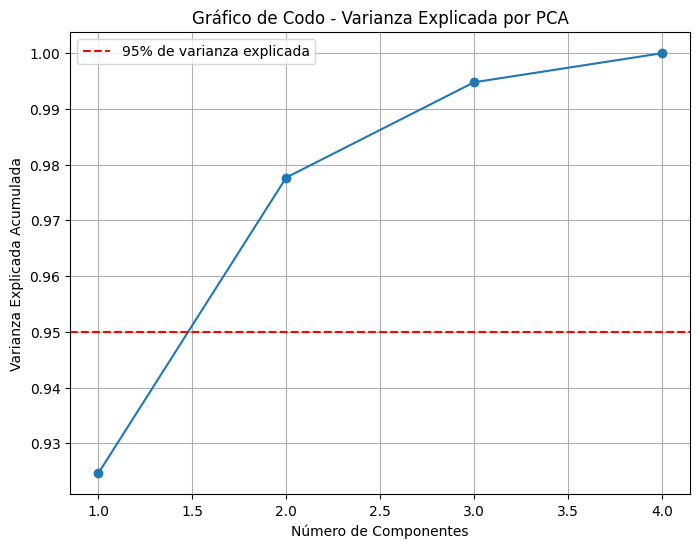

In [ ]:
# PCA sin limitar el número de componentes
pca_full = PCA()
pca_full.fit(X)

# Varianza explicada
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Gráfico de varianza explicada acumulada
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% de varianza explicada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Gráfico de Codo - Varianza Explicada por PCA')
plt.grid(True)
plt.legend()
plt.show()


# Condiciones que aseguran resultados significativos

Para que el Análisis de Componentes Principales (PCA) sea aplicado de forma exitosa, los datos deben cumplir con ciertas características y condiciones que aseguran resultados significativos. A continuación te las explico de forma clara:

✅ 1. Escalamiento adecuado de los datos
PCA es sensible a la escala de las variables, porque se basa en la varianza y la covarianza.

Si las variables están en diferentes escalas (por ejemplo, altura en metros y peso en kilogramos), las de mayor magnitud dominarán el análisis.

Por ello, se recomienda estandarizar los datos (media 0, desviación estándar 1) antes de aplicar PCA.

👉 Usa StandardScaler de scikit-learn para estandarizar.

✅ 2. Relación lineal entre variables
PCA solo captura relaciones lineales entre las variables.

Si la estructura de los datos es no lineal, PCA no la capturará bien.

Para relaciones no lineales, se puede considerar Kernel PCA o técnicas no lineales como t-SNE o UMAP.

✅ 3. Correlación entre variables
PCA funciona mejor cuando hay correlaciones significativas entre variables.

Si las variables son altamente correlacionadas, PCA puede reducir la dimensionalidad de forma efectiva.

Si las variables son independientes, PCA no reducirá mucho la dimensión, ya que cada componente explicará poca varianza.

✅ 4. No tener demasiados valores faltantes
PCA no maneja bien los valores nulos o NaN.

Es necesario limpiar o imputar los datos antes de aplicarlo.

Técnicas como la imputación por la media, la mediana o modelos más avanzados pueden ser útiles.

✅ 5. Tamaño de muestra suficiente
Para obtener resultados confiables, se recomienda tener más observaciones que variables:

Si
𝑛
≫
𝑝
n≫p: PCA es más estable.

Si
𝑝
≫
𝑛
p≫n: Puede usarse PCA, pero hay que tener cuidado con el sobreajuste y considerar técnicas como PCA regularizado.



# 📌 Objetivo del PCA como problema de optimización

## PCA como problema de optimización

El objetivo de PCA es encontrar una dirección $ \mathbf{w} \in \mathbb{R}^p $ (vector unitario) tal que, al proyectar los datos en esa dirección, la **varianza proyectada** sea máxima.

Supongamos una matriz de datos centrados en la media $ X \in \mathbb{R}^{n \times p} $, donde cada fila es una observación y cada columna una variable.

Queremos encontrar $ \mathbf{w} $ que maximice:

$$
\text{Var}(X \mathbf{w}) = \mathbf{w}^T \Sigma \mathbf{w}
$$

sujeto a la restricción de que $ \mathbf{w} $ sea un vector unitario:

$$
\|\mathbf{w}\|^2 = \mathbf{w}^T \mathbf{w} = 1
$$

---


# 🧮 Aplicación de multiplicadores de Lagrange

## Uso de multiplicadores de Lagrange

Planteamos el siguiente problema de optimización:

$$
\text{Maximizar } \mathbf{w}^T \Sigma \mathbf{w} \quad \text{sujeto a } \mathbf{w}^T \mathbf{w} = 1
$$

La función Lagrangiana es:

$$
\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T \Sigma \mathbf{w} - \lambda (\mathbf{w}^T \mathbf{w} - 1)
$$

Para encontrar el máximo, derivamos con respecto a $ \mathbf{w} $ e igualamos a cero:

$$
\nabla_{\mathbf{w}} \mathcal{L} = 2\Sigma \mathbf{w} - 2\lambda \mathbf{w} = 0
$$

$$
\Rightarrow \Sigma \mathbf{w} = \lambda \mathbf{w}
$$

Este es un **problema de valores propios**, donde:
- $ \mathbf{w} $ es un **vector propio** (dirección del componente principal).
- $ \lambda $ es el **valor propio** (varianza explicada por esa dirección).

---




#📌 Interpretación y supuestos necesarios

## Supuestos para aplicar esta optimización

Para que esta formulación funcione correctamente, los datos deben cumplir con los siguientes supuestos:

1. **Datos centrados**: Es esencial que los datos tengan media cero, ya que PCA busca direcciones de máxima **varianza** respecto al centro.

2. **Varianza finita y matriz de covarianza bien definida**:
   - $ \Sigma = \frac{1}{n-1} X^T X $ debe existir.
   - Los datos no deben tener colinealidad perfecta (para que $ \Sigma $ no sea singular).

3. **Linealidad de las relaciones**: El modelo busca combinaciones **lineales** de las variables. No captura relaciones no lineales.

4. **Variables numéricas**: PCA no es adecuado directamente para variables categóricas.

---

El primer componente principal es el vector propio de $ \Sigma $ asociado al **mayor valor propio**. Componentes subsiguientes se obtienen imponiendo **ortogonalidad** entre vectores.

---
